In [1]:
import os
os.environ["UNSLOTH_ENABLE_CUSTOM_LOSS"] = "0"
os.environ["TORCH_COMPILE_DISABLE"] = "1"

import torch
import gc
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments

gc.collect()
torch.cuda.empty_cache()

DATA_FILE = "phase1b_enron_train_reasoning_filtered.jsonl" 
BASE_MODEL_DIR = "base_llama3_model"
ADAPTER_DIR = "adapters/ENRON_Adapter"

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
print("Initiating Enron Email Agent Training Pipeline...")

if not os.path.exists(BASE_MODEL_DIR):
    raise FileNotFoundError(f"Base model not found at '{BASE_MODEL_DIR}'.")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL_DIR,
    max_seq_length = 2048, # Maximun context length
    dtype = None,
    load_in_4bit = True, # quantized model
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16, 
    target_modules = ["q_proj", "v_proj"], # both are enough for generating reasons
    lora_alpha = 16,
    lora_dropout = 0, 
    bias = "none",    
    use_gradient_checkpointing = True, 
    random_state = 3407,
)

Initiating Enron Email Agent Training Pipeline...
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 4060 Laptop GPU. Num GPUs = 1. Max memory: 7.996 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch Attention layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.2.1 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


In [3]:
print(f"\nLoading filtered dataset from {DATA_FILE}...")
dataset = load_dataset("json", data_files = DATA_FILE, split = "train")
print(f"Total training records loaded: {len(dataset)}")


Loading filtered dataset from phase1b_enron_train_reasoning_filtered.jsonl...
Total training records loaded: 4000


In [4]:
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
You are an AI Executive Assistant. Analyze the following corporate email thread.
Determine the sender's core intent, summarize the context, and extract ALL required action items.

CRITICAL RULES:
1. Identify who needs to do what.
2. If there are multiple action items, list all of them.
3. If the action matches a system function (e.g., schedule_meeting), use it. If it is a custom human task, describe it clearly in plain text.

Format your output EXACTLY like this:
Thought: [Your summary and intent analysis]
Action: [The extracted action item(s), tasks, or functions]

### Input:
{}

### Response:
{}"""

EOS_TOKEN = tokenizer.eos_token 

In [5]:
def formatting_prompts_func(examples):
    inputs = examples["input"]
    outputs = examples["output"]
    texts = []
    for input_text, output_text in zip(inputs, outputs):
        text = alpaca_prompt.format(input_text, output_text) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts }

dataset = dataset.map(formatting_prompts_func, batched = True)

# Create validation split for the loss curve
split_dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"] 

In [6]:
print(f"\nStarting Enron Training. Saving to {ADAPTER_DIR}...")

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    dataset_num_proc = 2, 
    packing = False, 

    args = TrainingArguments(
        per_device_train_batch_size = 1, 
        gradient_accumulation_steps = 8, 
        warmup_steps = 10,
        # max_steps = 300,        
        num_train_epochs = 3,   
        learning_rate = 2e-4, 
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(), 
        # eval_strategy = "steps",
        eval_strategy = "epoch", 
        logging_steps = 10,
        optim = "paged_adamw_8bit", 
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = ADAPTER_DIR,            
        overwrite_output_dir = True, 
    ),
)

trainer.train()


Starting Enron Training. Saving to adapters/ENRON_Adapter...


Unsloth: Tokenizing ["text"]:   0%|          | 0/3600 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]:   0%|          | 0/400 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,600 | Num Epochs = 3 | Total steps = 1,350
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 4,587,520 of 3,217,337,344 (0.14% trained)


Epoch,Training Loss,Validation Loss
1,1.405000,1.243541
2,1.332300,1.210593
3,1.272600,1.200542


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=1350, training_loss=1.4021658650151005, metrics={'train_runtime': 5545.3009, 'train_samples_per_second': 1.948, 'train_steps_per_second': 0.243, 'total_flos': 9.595492189315891e+16, 'train_loss': 1.4021658650151005, 'epoch': 3.0})

In [7]:
print(f"\nSaving Enron LoRA Adapter to {ADAPTER_DIR}...")
model.save_pretrained(ADAPTER_DIR) 
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Enron Adapter successfully trained and saved!")


Saving Enron LoRA Adapter to adapters/ENRON_Adapter...
Enron Adapter successfully trained and saved!


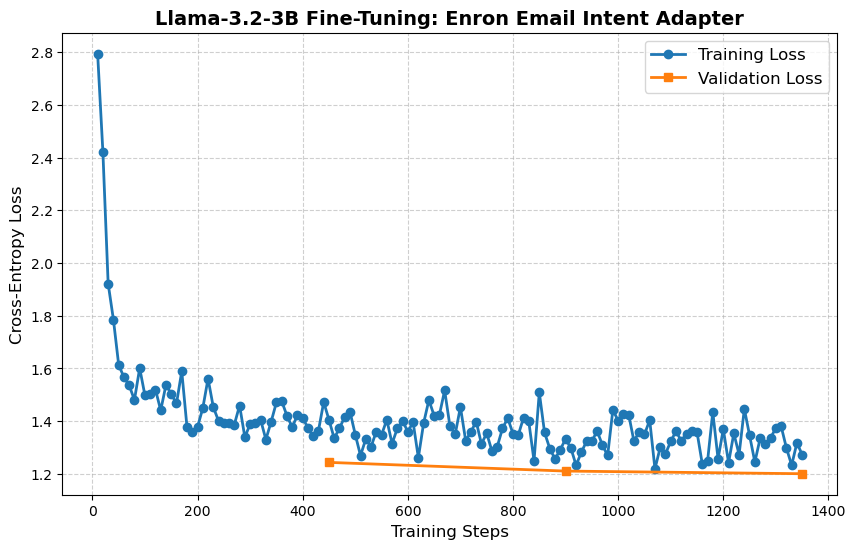

In [8]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_steps, train_loss, eval_steps, eval_loss = [], [], [], []

for entry in log_history:
    if "loss" in entry and "step" in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])
    elif "eval_loss" in entry and "step" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="Training Loss", color="#1f77b4", marker="o", linewidth=2)
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="Validation Loss", color="#ff7f0e", marker="s", linewidth=2)

plt.title("Llama-3.2-3B Fine-Tuning: Enron Email Intent Adapter", fontsize=14, fontweight="bold")
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("ENRON_Loss_Curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
# HARD SHUTDOWN & UNLOAD FROM GPU

import torch
import gc

print("Initiating VRAM Hard-Shutdown for Local Models...")

# 1. Track memory before cleanup
if torch.cuda.is_available():
    vram_before = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM Allocated Before: {vram_before:.2f} GB")

# 2. List of every heavy object that might be trapped in memory
heavy_objects = [
    'model', 'tokenizer', 'trainer', 'bertscore', 'rouge', 
    'dataset', 'train_dataset', 'eval_dataset', 'split_dataset',
    'inputs', 'outputs'
]

# 3. Delete them dynamically if they exist
for obj in heavy_objects:
    if obj in globals():
        print(f"Unloading '{obj}' from memory...")
        del globals()[obj]

# 4. Force aggressive Garbage Collection (Run twice to clear circular references)
gc.collect()
gc.collect()

# 5. Flush the GPU Cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()  # Clears memory shared between backend processes
    torch.cuda.synchronize()  # Waits for all GPU operations to completely finish
    
    # Track memory after cleanup
    vram_after = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM Allocated After:  {vram_after:.2f} GB")

print("\nGPU Memory Cleared. Your VRAM is now completely empty!")

Initiating VRAM Hard-Shutdown for Local Models...
VRAM Allocated Before: 2.19 GB
Unloading 'model' from memory...
Unloading 'tokenizer' from memory...
Unloading 'trainer' from memory...
Unloading 'dataset' from memory...
Unloading 'train_dataset' from memory...
Unloading 'eval_dataset' from memory...
Unloading 'split_dataset' from memory...
VRAM Allocated After:  0.75 GB

GPU Memory Cleared. Your VRAM is now completely empty!
